Q: Why can't we use Linear Regression for classification?

A: Linear Regression is used to predict continuos values ( wight, size, age ...), so it does not provide True or False answer

Q: What problem does Logistic Regression solve?

A: Classification it provide probability of the predicted value to classify it 

Q: Why are predictions between 0 and 1?

A: it represent the probability of class, the chances that those samples belong to predicted classes

Q: How is the final class decided?

A: choose the class with higher probability ( ex: prediction > 50% then True Else False)

Linear Regression VS Logistic Regression

| Linear Regression    | Logistic Regression                      |
| -------------------- | ---------------------------------------- |
| Regression           | Classification                           |
| Predicts numbers     | Predicts probabilities/classes           |
| Continuous output    | Output between 0 and 1                   |
| Uses Linear function | Uses Sigmoid function                    |
| MAE, RMSE, R²        | Accuracy, Precision, Recall, F1, ROC AUC |


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)

df = data.frame

#Explore the data
df.head(20)


#df.describe()
#df.info()
#df.isnull().sum()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,0


acs : 0.9473684210526315
ps : 0.9333333333333333
rs: 0.9859154929577465
f1  : 0.958904109589041


C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


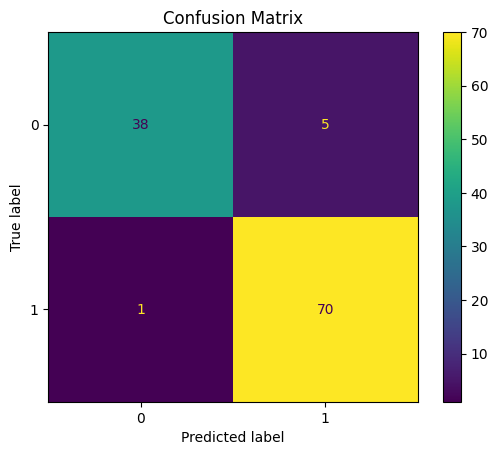

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred
})

#Compare
comparison.head(10)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

acs = accuracy_score(y_test, y_pred)
ps = precision_score(y_test, y_pred)
rs = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
#cm = confusion_matrix(y_test, y_pred)

print("acs :", acs)
print("ps :", ps)
print("rs:", rs)
print("f1  :", f1)

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()



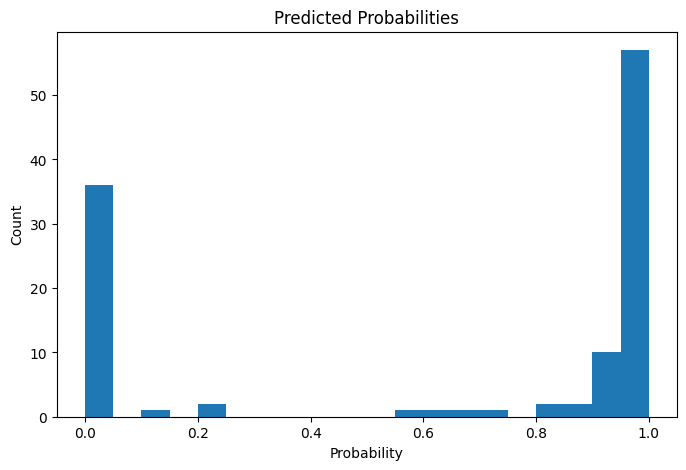

                    Feature  Coefficient
20             worst radius     1.378832
0               mean radius     1.321590
11            texture error     0.620128
1              mean texture     0.278534
12          perimeter error     0.057022
2            mean perimeter     0.052426
10             radius error     0.043930
3                 mean area    -0.002339
19  fractal dimension error    -0.004245
14         smoothness error    -0.004860
9    mean fractal dimension    -0.015528
18           symmetry error    -0.018168
17     concave points error    -0.018549
23               worst area    -0.026834
15        compactness error    -0.048718
4           mean smoothness    -0.051466
13               area error    -0.054386
16          concavity error    -0.067782
29  worst fractal dimension    -0.068254
8             mean symmetry    -0.076910
24         worst smoothness    -0.091333
22          worst perimeter    -0.136762
7       mean concave points    -0.144750
5          mean 

In [3]:


probabilities = model.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,5))

plt.hist(probabilities, bins=20)

plt.xlabel("Probability")

plt.ylabel("Count")

plt.title("Predicted Probabilities")

plt.show()

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef = coef.sort_values(
    by="Coefficient",
    ascending=False
)

print(coef)

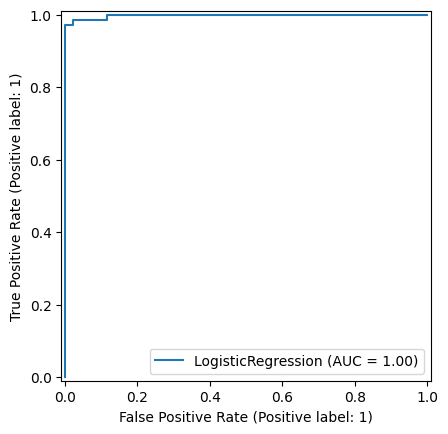

In [4]:

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()